In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

file = Path("../data/repeated_10_scale_250/100206_repeated10_scale250.graphml")

node_num_cols = [
    "dn_position_x", "dn_position_y", "dn_position_z", "dn_correspondence_id"
]

edge_num_cols = [
    "fiber_length_mean", "FA_mean", "number_of_fibers"
]

G = nx.read_graphml(file)

node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append({
        "file": file.name,
        "path": str(file),
        "node_id": node_id,
        **attrs
    })

nodes_df = pd.DataFrame(node_records)

for col in node_num_cols:
    if col in nodes_df.columns:
        nodes_df[col] = pd.to_numeric(nodes_df[col], errors="coerce")

edge_records = []
for u, v, attrs in G.edges(data=True):
    edge_records.append({
        "file": file.name,
        "path": str(file),
        "source": u,
        "target": v,
        **attrs
    })

edges_df = pd.DataFrame(edge_records)

for col in edge_num_cols:
    if col in edges_df.columns:
        edges_df[col] = pd.to_numeric(edges_df[col])


display(nodes_df.head())
display(edges_df.head())

,file,path,node_id,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere
0,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,1,36.000000,74.143590,7.584615,1,cortical,lateralorbitofrontal_1,rh.lateralorbitofrontal_1,right
1,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,29.917241,78.565517,13.675862,2,cortical,lateralorbitofrontal_2,rh.lateralorbitofrontal_2,right
2,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,3,28.670673,80.062500,7.425481,3,cortical,lateralorbitofrontal_3,rh.lateralorbitofrontal_3,right
3,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,4,36.979933,79.662207,7.926421,4,cortical,lateralorbitofrontal_4,rh.lateralorbitofrontal_4,right
4,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,5,37.913043,85.681159,7.526570,5,cortical,lateralorbitofrontal_5,rh.lateralorbitofrontal_5,right


,file,path,source,target,fiber_length_mean,FA_mean,number_of_fibers
0,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,224,36.699456,0.163246,13.000
1,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,225,20.892134,0.186631,40.250
2,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,226,14.545893,0.230742,261.250
3,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,227,22.152100,0.271936,41.125
4,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,222,12.405001,0.294189,2.625


A shape: (370, 370)
symmetric: True


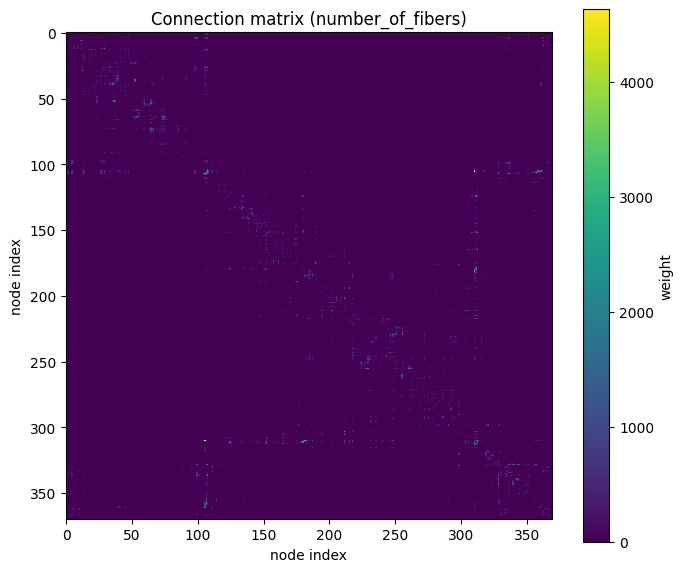

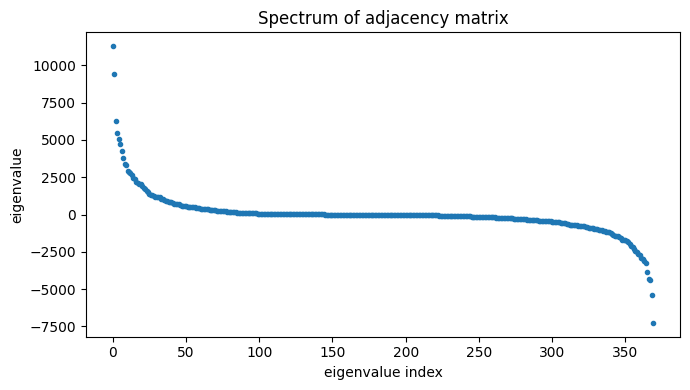

In [ ]:
df = edges_df.drop(columns=["file", "path"])

# Examples: "number_of_fibers", "FA_mean", "fiber_length_mean"
weight_col = "number_of_fibers"

# --- collect nodes and make index mapping ---
nodes = np.sort(pd.unique(df[["source", "target"]].values.ravel()))
node_to_idx = {node: i for i, node in enumerate(nodes)}
n = len(nodes)

# --- initialize adjacency matrix ---
A = np.zeros((n, n), dtype=float)

# --- fill matrix symmetrically ---
for _, row in df.iterrows():
    i = node_to_idx[row["source"]]
    j = node_to_idx[row["target"]]

    w = 1.0 if weight_col is None else float(row[weight_col])

    A[i, j] = w
    A[j, i] = w   # make undirected / symmetric

# optional: clear diagonal
np.fill_diagonal(A, 0)

print("A shape:", A.shape)
print("symmetric:", np.allclose(A, A.T))

# --- plot connection matrix ---
plt.figure(figsize=(7, 6))
plt.imshow(A, interpolation="nearest")
plt.colorbar(label="weight" if weight_col else "connection")
plt.title(f"Connection matrix ({'binary' if weight_col is None else weight_col})")
plt.xlabel("node index")
plt.ylabel("node index")
plt.tight_layout()
plt.show()

# --- spectrum of adjacency matrix ---
eigvals = np.linalg.eigvalsh(A)   # for symmetric matrices

plt.figure(figsize=(7, 4))
plt.plot(np.sort(eigvals)[::-1], marker=".", linestyle="none")
plt.title("Spectrum of adjacency matrix")
plt.xlabel("eigenvalue index")
plt.ylabel("eigenvalue")
plt.tight_layout()
plt.show()

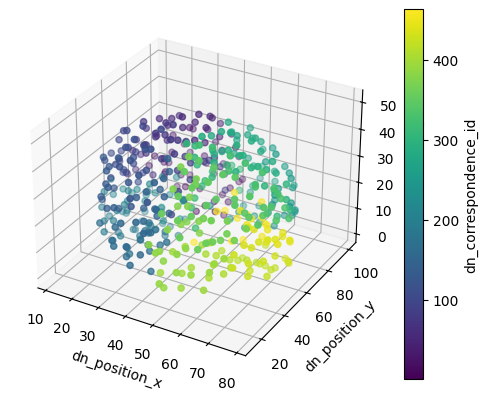

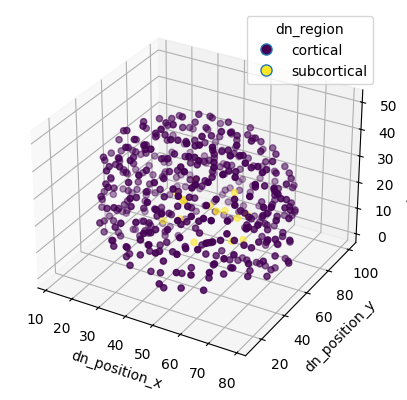

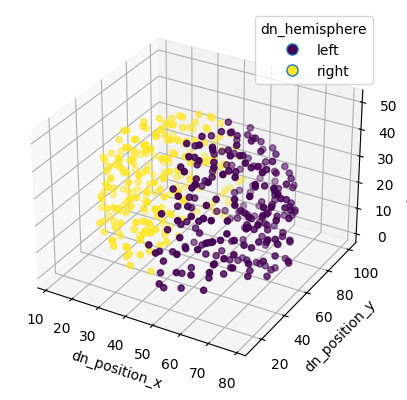

In [2]:
from pandas.api.types import is_numeric_dtype

def plot_3d(df, x="dn_position_x", y="dn_position_y", z="dn_position_z", color_by=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    if color_by is None:
        ax.scatter(df[x], df[y], df[z])
    else:
        s = df[color_by]

        if is_numeric_dtype(s):
            sc = ax.scatter(df[x], df[y], df[z], c=s)
            fig.colorbar(sc, ax=ax, label=color_by)
        else:
            categories = pd.Categorical(s)
            codes = categories.codes

            sc = ax.scatter(df[x], df[y], df[z], c=codes)

            if len(categories.categories) < 10:
                handles = []
                for code, label in enumerate(categories.categories):
                    handles.append(
                        plt.Line2D(
                            [0], [0],
                            marker="o",
                            linestyle="",
                            label=str(label),
                            markerfacecolor=sc.cmap(sc.norm(code)),
                            markersize=8,
                        )
                    )
                ax.legend(handles=handles, title=color_by)

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    plt.show()
    

plot_3d(nodes_df, color_by="dn_correspondence_id") 
plot_3d(nodes_df, color_by="dn_region")   
plot_3d(nodes_df, color_by="dn_hemisphere")


Spearman rho: 0.08087099832118637

                   fiber_length_mean   FA_mean  number_of_fibers
fiber_length_mean           1.000000  0.080871         -0.374497
FA_mean                     0.080871  1.000000          0.042448
number_of_fibers           -0.374497  0.042448          1.000000


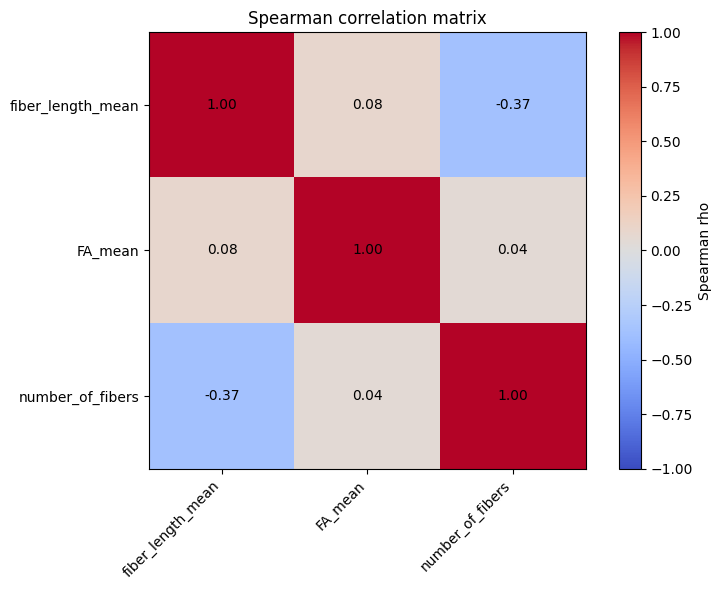

In [3]:
def spearman_two_cols(df, col1, col2):
    """
    Spearman correlation between two columns using pandas only.
    Returns a single float (rho).
    """
    tmp = df[[col1, col2]].dropna()
    if len(tmp) < 2:
        return np.nan
    return tmp[col1].corr(tmp[col2], method="spearman")


def spearman_corr_matrix(df, cols):
    """
    Spearman correlation matrix for selected columns using pandas only.
    """
    return df[cols].corr(method="spearman")


def plot_corr_matrix(corr, title="Spearman correlation matrix"):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            txt = "nan" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Spearman rho")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
    
cols = ["fiber_length_mean", "FA_mean", "number_of_fibers"]

# two columns
rho = spearman_two_cols(edges_df, "fiber_length_mean", "FA_mean")
print("Spearman rho:", rho, end="\n\n")

# full matrix
corr = spearman_corr_matrix(edges_df, cols)
print(corr)

plot_corr_matrix(corr)  

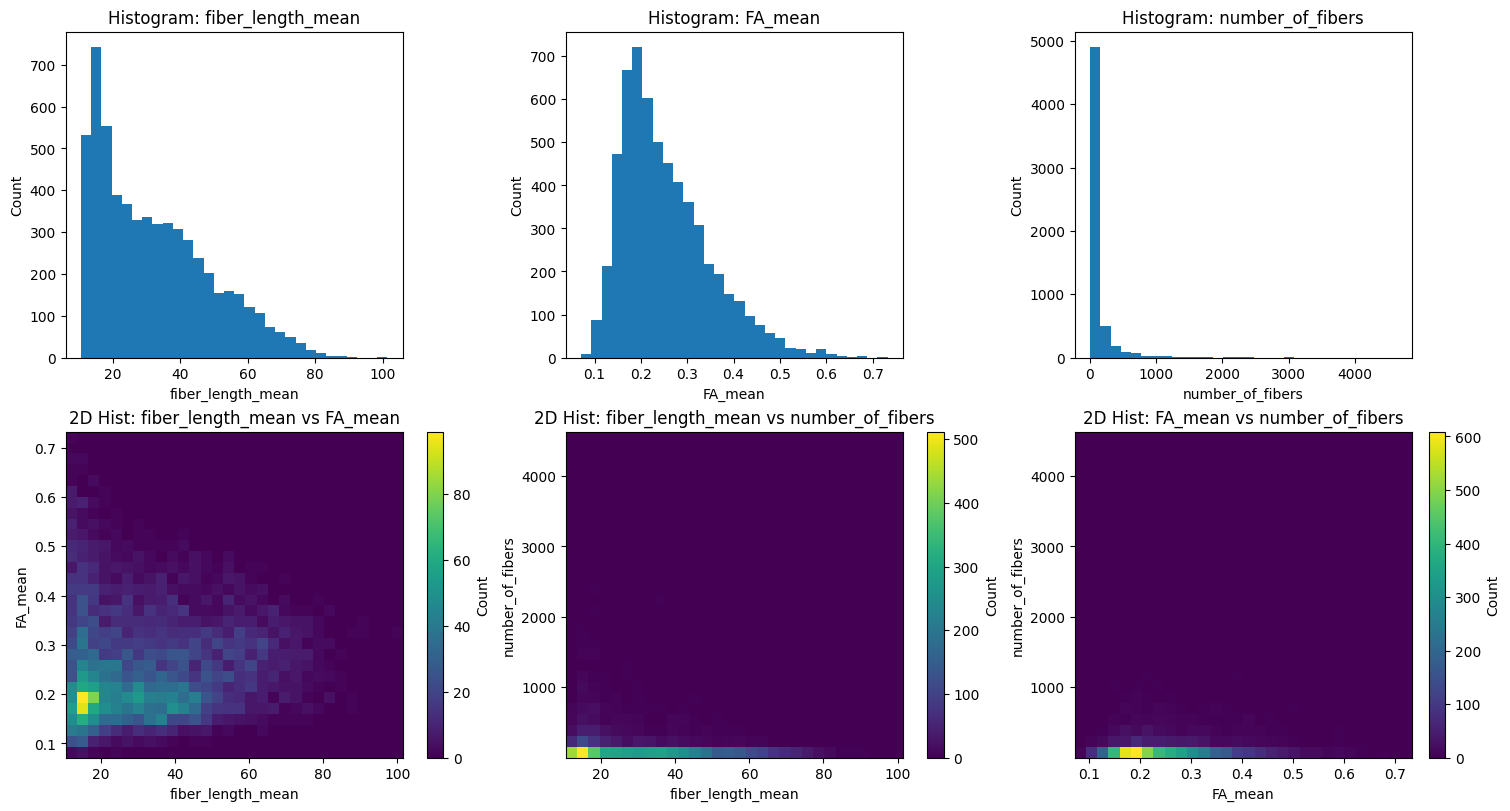

In [4]:
from itertools import combinations

def plot_histograms_combined(df, cols, bins=30, figsize=(15, 8)):
    pairs = list(combinations(cols, 2))

    n_top = len(cols)
    n_bottom = len(pairs)
    n_cols = max(n_top, n_bottom)

    fig, axes = plt.subplots(2, n_cols, figsize=figsize, constrained_layout=True)

    # Make axes always 2D
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    # Top row: 1D histograms
    for i, col in enumerate(cols):
        ax = axes[0, i]
        ax.hist(df[col].dropna(), bins=bins)
        ax.set_title(f"Histogram: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # Hide unused top-row axes
    for i in range(n_top, n_cols):
        axes[0, i].set_visible(False)

    # Bottom row: 2D histograms
    for i, (col1, col2) in enumerate(pairs):
        ax = axes[1, i]
        tmp = df[[col1, col2]].dropna()
        h = ax.hist2d(tmp[col1], tmp[col2], bins=bins)
        ax.set_title(f"2D Hist: {col1} vs {col2}")
        ax.set_xlabel(col1)
        ax.set_ylabel(col2)
        fig.colorbar(h[3], ax=ax, label="Count")

    # Hide unused bottom-row axes
    for i in range(n_bottom, n_cols):
        axes[1, i].set_visible(False)

    plt.show()


cols = ["fiber_length_mean", "FA_mean", "number_of_fibers"]
plot_histograms_combined(edges_df, cols)